In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!rm -rf /content/Data_300
!rm -rf /content/Data_Full

!unzip -q /content/drive/MyDrive/AppML/jpegs_all_300m.zip -d /content/Data_300
print('Done unzipping')

Done unzipping


In [ ]:
import os
import re
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
from sklearn.metrics import mean_absolute_error, r2_score
from tqdm.auto import tqdm

print(f"PyTorch {torch.__version__}")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

PyTorch 2.11.0+cu128
Using device: cuda


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  CONFIGURE THESE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATA_DIR    = '/content/Data_300'   # ← change this
IMG_SIZE    = 600
BATCH_SIZE  = 8
NUM_SAMPLES = -1
EPOCHS      = 50
LR          = 1e-3
VAL_SPLIT   = 0.2
DROPOUT     = 0.3
PATIENCE    = 10       # early stopping patience
OUTPUT_DIR  = "output"
SEED        = 42
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

os.makedirs(OUTPUT_DIR, exist_ok=True)

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

In [ ]:
def extract_target_from_filename(filename: str) -> int:
    """Return the last integer found in the filename (before extension)."""
    stem = Path(filename).stem
    numbers = re.findall(r"\d+", stem)
    if not numbers:
        raise ValueError(f"No numeric target found in filename: {filename}")
    return int(numbers[-1])


class PeopleCountDataset(Dataset):
    """Loads images from a directory; target = last number in filename."""

    VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

    def __init__(self, root_dir: str, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []

        for f in sorted(self.root_dir.iterdir()):
            if f.suffix.lower() in self.VALID_EXT:
                try:
                    target = extract_target_from_filename(f.name)
                    self.samples.append((f, target))
                except ValueError:
                    print(f"  ⚠ Skipping {f.name} — no target in name")

        if not self.samples:
            raise FileNotFoundError(
                f"No valid images in {root_dir}. Check the path and filename format."
            )

        targets = [t for _, t in self.samples]
        print(f"✓ Loaded {len(self.samples)} images")
        print(f"  Target range: {min(targets)} – {max(targets)}  "
              f"(mean {np.mean(targets):.1f}, std {np.std(targets):.1f})")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, target = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(target, dtype=torch.float32)

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [ ]:
# Load full dataset
full_dataset = PeopleCountDataset(DATA_DIR, transform=None)
full_dataset.samples = full_dataset.samples[:NUM_SAMPLES]

# ── Balance: equal number of 0-people vs has-people ──────────
zero_samples = [s for s in full_dataset.samples if s[1] == 0]
nonzero_samples = [s for s in full_dataset.samples if s[1] > 0]

# Downsample the larger group to match the smaller group
n_balanced = min(len(zero_samples), len(nonzero_samples))
random.shuffle(zero_samples)
random.shuffle(nonzero_samples)
full_dataset.samples = zero_samples[:n_balanced] + nonzero_samples[:n_balanced]
random.shuffle(full_dataset.samples)

print(f"Balanced: {n_balanced} zero-people + {n_balanced} with-people = {len(full_dataset.samples)} total")
# ──────────────────────────────────────────────────────────────

val_size = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size

train_subset, val_subset = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

train_dataset = PeopleCountDataset(DATA_DIR, transform=train_transform)
train_dataset.samples = [full_dataset.samples[i] for i in train_subset.indices]

val_dataset = PeopleCountDataset.__new__(PeopleCountDataset)
val_dataset.root_dir = full_dataset.root_dir
val_dataset.transform = val_transform
val_dataset.samples = [full_dataset.samples[i] for i in val_subset.indices]

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True,
)

print(f"Train: {len(train_dataset)} samples  |  Val: {len(val_dataset)} samples")

✓ Loaded 9587 images
  Target range: 0 – 899  (mean 12.0, std 48.5)
Balanced: 3914 zero-people + 3914 with-people = 7828 total
✓ Loaded 9587 images
  Target range: 0 – 899  (mean 12.0, std 48.5)
Train: 6263 samples  |  Val: 1565 samples


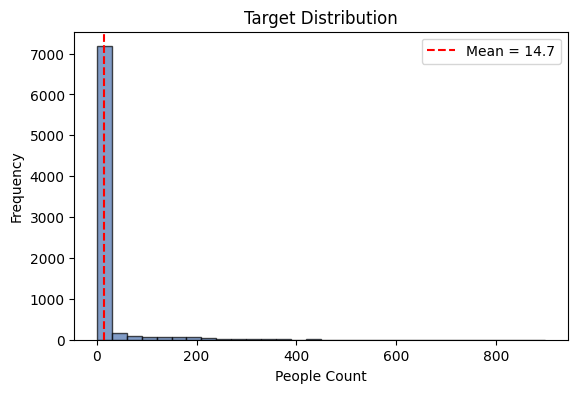

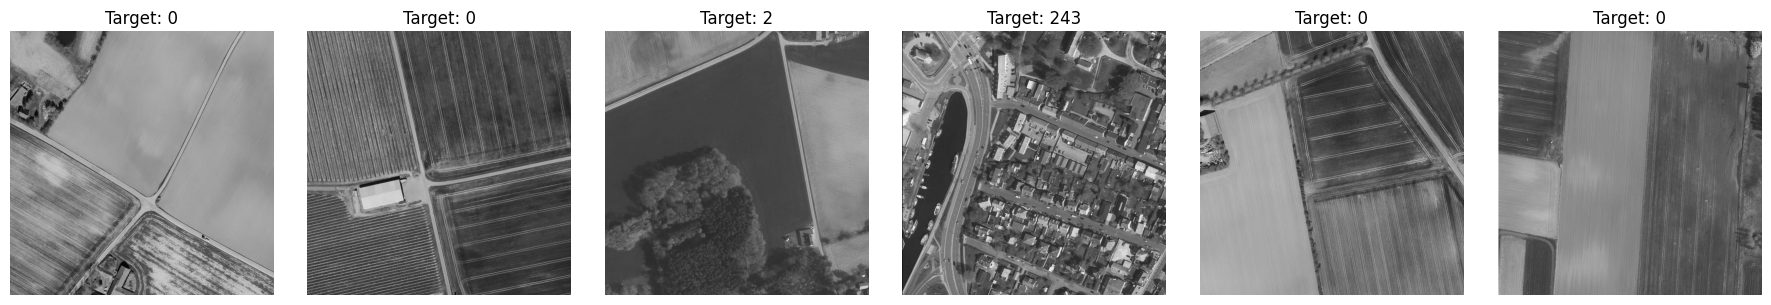

In [ ]:
targets = [t for _, t in full_dataset.samples]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(targets, bins=30, edgecolor="black", alpha=0.7, color="#4C72B0")
axes[0].set_xlabel("People Count")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Target Distribution")
axes[0].axvline(np.mean(targets), color="red", linestyle="--", label=f"Mean = {np.mean(targets):.1f}")
axes[0].legend()

# Show a few sample images
sample_indices = random.sample(range(len(full_dataset)), min(6, len(full_dataset)))
axes[1].set_visible(False)

fig2, axes2 = plt.subplots(1, min(6, len(full_dataset)), figsize=(18, 3))
if not isinstance(axes2, np.ndarray):
    axes2 = [axes2]
for ax, idx in zip(axes2, sample_indices):
    path, target = full_dataset.samples[idx]
    img = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    ax.imshow(img)
    ax.set_title(f"Target: {target}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from torch.utils.checkpoint import checkpoint

class PeopleCountCNN(nn.Module):
    """
    EfficientNet-B3 backbone pretrained on ImageNet, fine-tuned for
    people-count regression on 600x600 images.

    Feature map progression (600x600 input):
      Stem          600 -> 300
      MBConv stage  300 -> 150 -> 75 -> 38 -> 19 -> 19
      Head features          19x19 x 1536
      AdaptiveAvgPool                  1x1 x 1536
      Regressor          1536 -> 512 -> 128 -> 1
    """

    def __init__(self, dropout: float = 0.3):
        super().__init__()

        # ── Backbone ──────────────────────────────────────────────────
        # Build on CPU first, move to device after clearing GPU memory
        backbone = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)

        # Store each stage as a separate module so we can checkpoint them
        # individually. backbone.features is a Sequential of 9 stages (0-8).
        self.stages = nn.ModuleList(backbone.features)
        self.pool   = backbone.avgpool           # AdaptiveAvgPool2d(1)

        # Freeze all backbone stages, then unfreeze the last three
        for param in self.stages.parameters():
            param.requires_grad = False
        for stage in [self.stages[6], self.stages[7], self.stages[8]]:
            for param in stage.parameters():
                param.requires_grad = True

        # ── Regression head ───────────────────────────────────────────
        in_features = backbone.classifier[1].in_features  # 1536
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, 512),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.SiLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        # Gradient checkpointing on each stage: recomputes activations during
        # backward instead of storing them — ~4x memory reduction for ~15% extra compute.
        # use_reentrant=False is the modern API (avoids a deprecation warning).
        for stage in self.stages:
            x = checkpoint(stage, x, use_reentrant=False)
        x = self.pool(x)
        return self.regressor(x).squeeze(-1)


# ── Clear any leftover GPU state from previous runs ───────────────────────────
if "model" in dir():
    del model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    free, total_mem = torch.cuda.mem_get_info()
    print(f"GPU memory free before loading: {free/1024**3:.2f} GiB / {total_mem/1024**3:.2f} GiB")

model = PeopleCountCNN(dropout=DROPOUT).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)")
print(model.regressor)


GPU memory free before loading: 0.01 GiB / 14.56 GiB


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 1.81 MiB is free. Process 1243 has 14.30 GiB memory in use. Including non-PyTorch memory, this process has 252.00 MiB memory in use. Of the allocated memory 128.12 MiB is allocated by PyTorch, and 5.88 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [ ]:
criterion = nn.MSELoss()

# Differential learning rates: backbone gets 10× lower LR than the head.
# The pretrained weights are already good — we nudge them, not blast them.
optimizer = optim.AdamW([
    {"params": [p for p in model.stages.parameters() if p.requires_grad],
     "lr": LR * 0.1,  "weight_decay": 1e-4},
    {"params": model.regressor.parameters(),
     "lr": LR,        "weight_decay": 1e-4},
])

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)


In [ ]:
# Automatic mixed precision: forward pass in fp16, loss scaling keeps gradients stable.
# Halves activation memory and speeds up compute on Tensor Core GPUs.
scaler = torch.amp.GradScaler("cuda")

# MPS workaround: some ops need float32 fallback
if device.type == "mps":
    import os
    os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    all_preds, all_targets = [], []

    for imgs, targets in tqdm(loader, desc="  Training", leave=False):
        imgs    = imgs.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            preds = model(imgs)
            loss  = criterion(preds, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * imgs.size(0)
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    mae = mean_absolute_error(all_targets, all_preds)
    return epoch_loss, mae


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds, all_targets = [], []

    for imgs, targets in loader:
        imgs    = imgs.to(device)
        targets = targets.to(device)

        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            preds = model(imgs)
            loss  = criterion(preds, targets)

        running_loss += loss.item() * imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    mae = mean_absolute_error(all_targets, all_preds)
    r2  = r2_score(all_targets, all_preds) if len(set(all_targets)) > 1 else 0.0
    return epoch_loss, mae, r2, np.array(all_preds), np.array(all_targets)


In [ ]:
import subprocess, os

# Show all processes holding GPU memory
result = subprocess.run(['fuser', '/dev/nvidia0'], capture_output=True, text=True)
pids = result.stdout.strip().split()
my_pid = str(os.getpid())
print(f'My PID: {my_pid}')
print(f'PIDs using GPU: {pids}')

# Kill any GPU process that isn't this notebook kernel
for pid in pids:
    if pid != my_pid:
        print(f'Killing stale process {pid}...')
        subprocess.run(['kill', '-9', pid])

import torch
torch.cuda.empty_cache()
free, total = torch.cuda.mem_get_info()
print(f'GPU free after cleanup: {free/1024**3:.2f} GiB / {total/1024**3:.2f} GiB')


In [ ]:
best_val_loss = float("inf")
patience_counter = 0
history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}

pbar = tqdm(range(1, EPOCHS + 1), desc="Training")

for epoch in pbar:
    train_loss, train_mae = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_mae, val_r2, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_mae"].append(train_mae)
    history["val_mae"].append(val_mae)

    pbar.set_postfix({
        "t_loss": f"{train_loss:.4f}",
        "v_loss": f"{val_loss:.4f}",
        "v_mae": f"{val_mae:.2f}",
        "v_r2": f"{val_r2:.3f}",
    })

    # Early stopping + checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": val_loss,
            "val_mae": val_mae,
        }, os.path.join(OUTPUT_DIR, "best_model.pth"))
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏹ Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
            break

print(f"\n✓ Training complete — best val loss: {best_val_loss:.4f}")

Training:   0%|          | 0/50 [00:00<?, ?it/s]

  Training:   0%|          | 0/196 [00:00<?, ?it/s]